Tutorial 2 (CH-4124)

####
Read and inspect a CSV

Read a CSV, preview structure, and count rows where a chosen column is greater than a threshold.
####

In [ ]:
import pandas as pd

# Path to a CSV
path = "/content/sample_beer_lambert.csv"

df = pd.read_csv(path)  # TO DO: read the CSV with pd.read_csv(path)
print(df.head())
print(df.info())
print(df.describe())

mask = df["absorbance_A"] > 0  # TO DO: boolean mask, e.g., df["absorbance_A"] > 0
count_positive = mask.sum()  # TO DO: mask.sum()
print("rows with condition for absorbance_A:", count_positive)

   concentration_mol_L  replicate  absorbance_A
0                0.000          1        0.0050
1                0.000          2       -0.0032
2                0.000          3        0.0017
3                0.002          1        0.2448
4                0.002          2        0.2401
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   concentration_mol_L  33 non-null     float64
 1   replicate            33 non-null     int64  
 2   absorbance_A         33 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 924.0 bytes
None
       concentration_mol_L  replicate  absorbance_A
count            33.000000  33.000000     33.000000
mean              0.010000   2.000000      1.196403
std               0.006423   0.829156      0.781941
min               0.000000   1.000000     -0.003200
25%               0.004000   1.000000   

###Scatter with style controls

Make a scatter of one column vs another, then adjust style parameters.

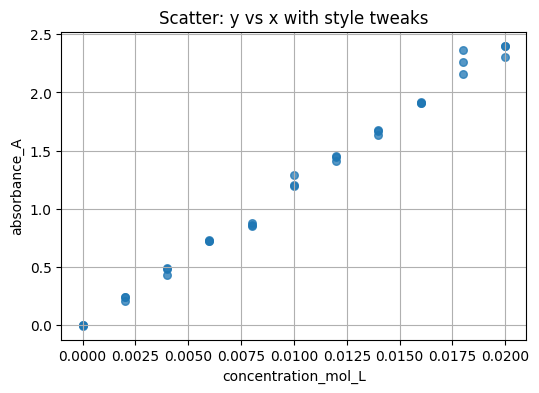

In [ ]:
import matplotlib.pyplot as plt

# Choose columns to plot
xcol = "concentration_mol_L"         # TO DO: e.g.,concentration
ycol = "absorbance_A"       # TO DO: e.g.,absorbance

# Style controls — change and re-run
point_size = 30   # TO DO: e.g., 30
alpha_val  =  0.76  # TO DO: e.g., 0.8
marker_sym =  "o"  # TO DO: e.g., "o"

plt.figure(figsize=(6, 4))
plt.scatter(df[xcol], df[ycol], s=point_size, alpha=alpha_val, marker=marker_sym)  # TO DO: e.g.,point_size, alpha_val, marker_sym

plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title("Scatter: y vs x with style tweaks")
plt.grid(True)

 Group, summarize, and draw error bars

Group by a key and plot group means with standard deviation as error bars.

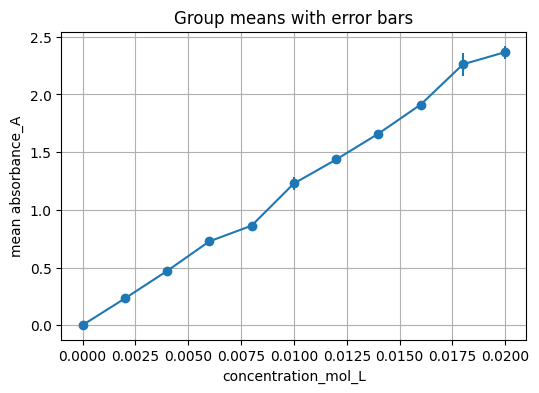

In [ ]:
key_col = xcol    # TO DO
val_col = ycol   # TO DO

summary = (
    df.groupby(key_col)[val_col]
      .agg(["mean", "std", "count"])
      .reset_index()
)

x = summary[key_col].to_numpy()
y = summary["mean"].to_numpy()
yerr = summary["std"].to_numpy()  # TO DO: standard deviation array

plt.figure(figsize=(6, 4))
plt.errorbar(x, y, yerr=yerr, fmt="o-")
plt.xlabel(key_col)
plt.ylabel(f"mean {val_col}")
plt.title("Group means with error bars")
plt.grid(True)

New dataset — organic synthesis yields

Work with organic_synthesis_yields.csv which has columns reaction_id, temperature_C, time_min, yield_percent. The yields are skewed toward lower values but still include some high yields. Tasks:

Read the CSV
Scatter temperature_C vs yield_percent
Color points by time_min using c=... and cmap=...
Build a pivot on temperature_C by time_min for yield_percent and draw a heatmap
Draw a histogram of yield_percent with different bins

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Option A — read the provided CSV
path = "./organic_synthesis_yields.csv"



df_y = pd.read_csv(path)  # TO DO: pd.read_csv(path)
df_y.head()

,reaction_id,temperature_C,time_min,yield_percent
0,63,80,50,3.0
1,177,70,170,28.6
2,34,65,180,22.6
3,167,105,230,51.7
4,94,65,130,24.9


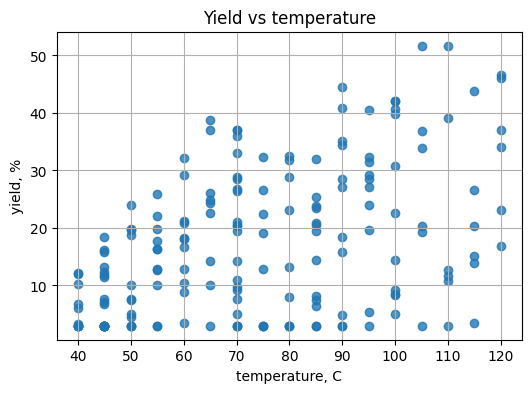

In [ ]:
# 2) Scatter temperature vs yield
plt.figure(figsize=(6, 4))
plt.scatter(df_y["temperature_C"], df_y["yield_percent"], alpha=0.8)  # TO DO: SEE NEXT TWO LINES
plt.xlabel("temperature, C")
plt.ylabel("yield, %")
plt.title("Yield vs temperature")
plt.grid(True)

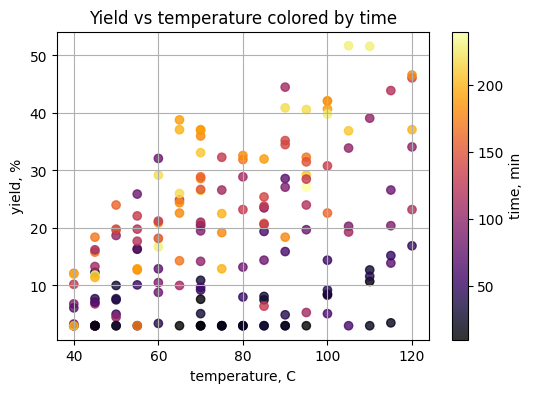

In [ ]:
# 3) Color by time
plt.figure(figsize=(6, 4))
plt.scatter(df_y["temperature_C"], df_y["yield_percent"],
            c=df_y["time_min"] , cmap="inferno", alpha=0.8)  # TO DO: C = see next line
plt.colorbar(label="time, min")
plt.xlabel("temperature, C")
plt.ylabel("yield, %")
plt.title("Yield vs temperature colored by time")
plt.grid(True)

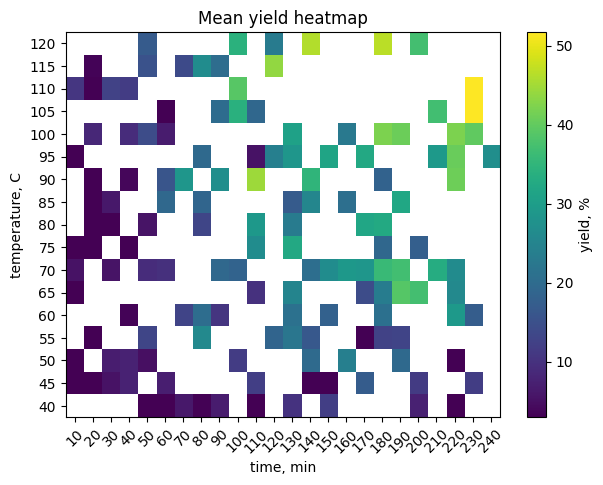

In [ ]:
# 4) Pivot to a 2D grid and heatmap
pivot = df_y.pivot_table(index="temperature_C", columns="time_min",
                         values="yield_percent", aggfunc="mean")
plt.figure(figsize=(7, 5))
plt.imshow(pivot.to_numpy(), aspect="auto", origin="lower")
plt.colorbar(label="yield, %")
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=45)
plt.xlabel("time, min")
plt.ylabel("temperature, C")
plt.title("Mean yield heatmap")
plt.grid(False)

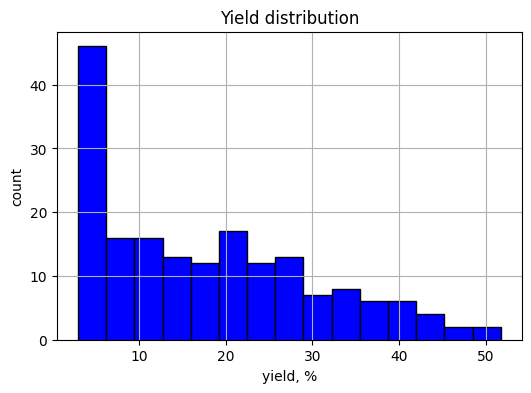

In [ ]:
# 5) Histogram of yields
plt.figure(figsize=(6, 4))
plt.hist(df_y["yield_percent"] , bins=15 , edgecolor="black" , color = "blue") # TO DO: try 15, 25, 40 for yield in histgram
plt.xlabel("yield, %")
plt.ylabel("count")
plt.title("Yield distribution")
plt.grid(True)

### Box and violin by binned temperature

Bin temperature_C into categories and compare yield distributions across bins.

/tmp/ipykernel_1505/1572024144.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [grp["yield_percent"].to_numpy() for name, grp in df_y.groupby("temp_bin")]  # TO DO
/tmp/ipykernel_1505/1572024144.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


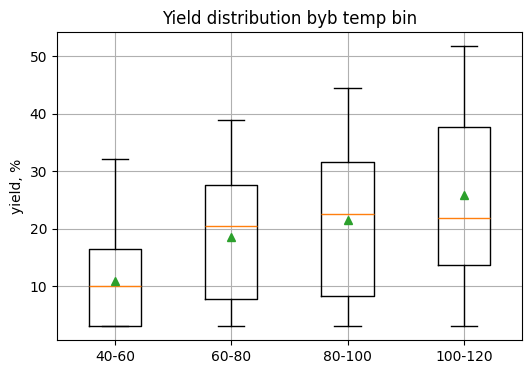

In [ ]:
# Define bins and labels for temperature
bins =  40, 60, 80, 100, 120
labels =  "40-60", "60-80", "80-100", "100-120"

df_y = df_y.copy() # TO DO: make a copy
df_y["temp_bin"] = pd.cut(df_y["temperature_C"], bins=bins, labels=labels, include_lowest=True)  # TO DO: column is df_y["temperature_C"]

# Build groups for violin or box plot
groups = [grp["yield_percent"].to_numpy() for name, grp in df_y.groupby("temp_bin")]  # TO DO

plt.figure(figsize=(6, 4))
# Choose one:
plt.boxplot(groups, labels=labels, showmeans=True)
#plt.violinplot(groups, showmeans=True)
plt.xticks(range(1, len(labels) + 1) , labels) # TO DO: use range from 1 to len(labels) + 1 for labels
plt.ylabel("yield, %")
plt.title("Yield distribution byb temp bin")
plt.grid(True)